In [41]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import seaborn as sns
import matplotlib.pyplot as plt

### Feature engineering
For each column in `feature_engineering_cols`, it can add:
- `col_lagN`: value from N days earlier.
- `col_rollN`: rolling mean over the previous N days. This is past-only because the series is shifted before rolling.
- `col_diffN`: change versus N days earlier.
- `col_slopeN`: rolling linear trend over the previous N days.

Use the candidate window variables below to add more lag/rolling options, then use the relevance scan to check whether they help predict `cycle_phase`.


In [42]:
# -------------------------
# 1) Feature engineering + cleanup helpers
# -------------------------
def missing_value_summary(df: pd.DataFrame) -> pd.DataFrame:
    missing_count = df.isna().sum().sort_values(ascending=False)
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    return pd.DataFrame({
        "missing_count": missing_count,
        "missing_pct": missing_pct.round(2),
    })


def drop_high_missing_columns(
    df: pd.DataFrame,
    threshold_pct=40,
    protected_cols=(),
    label="columns",
):
    summary = missing_value_summary(df)
    protected_cols = set(protected_cols)
    cols_to_drop = [
        c for c in df.columns
        if c not in protected_cols and summary.loc[c, "missing_pct"] > threshold_pct
    ]

    if cols_to_drop:
        print(f"Dropping {len(cols_to_drop)} {label} with >{threshold_pct}% missing:")
        print(cols_to_drop)
        df = df.drop(columns=cols_to_drop)
    else:
        print(f"No {label} above {threshold_pct}% missing.")

    return df, cols_to_drop, missing_value_summary(df)


def add_time_features(df: pd.DataFrame, cols, lags=(1,2), rolls=(7,14), diffs=(1,), slopes=(5,)):
    df = df.sort_values("date").copy()
    new_features = {}

    for col in cols:
        for lag in lags:
            new_features[f"{col}_lag{lag}"] = df[col].shift(lag)

        # Past-only rolling means: shift first, then roll
        s = df[col].shift(1)
        for w in rolls:
            new_features[f"{col}_roll{w}"] = s.rolling(w, min_periods=max(3, w//3)).mean()

        for d in diffs:
            new_features[f"{col}_diff{d}"] = df[col].diff(d)

        # Rolling linear slope: positive = rising trend, negative = falling trend
        for w in slopes:
            new_features[f"{col}_slope{w}"] = s.rolling(w, min_periods=3).apply(
                lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True
            )

    return pd.concat([df, pd.DataFrame(new_features, index=df.index)], axis=1)


In [ ]:
# -------------------------
# 2) Read Data
# -------------------------
DATA_FILE = Path("data/garmin_data_730days/garmin_data_730days.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path("/home/elsa/projects/garmin") / DATA_FILE

RAW_MISSING_DROP_PCT = 40
protected_raw_cols = ["date", "is_period", "cycle_phase", "garmin_predicted_fertile"]

df = pd.read_csv(DATA_FILE)

# Preprocessing: fetched CSVs carry raw calendar booleans (or older raw
# cycle_phase Period / Not logged). Derive the Early-follicular / Late-luteal anchor windows
# here, where their length is a tunable modelling choice.
import sys
_REPO_ROOT = Path.cwd() if (Path.cwd() / "preprocessing").exists() else Path("/home/elsa/projects/garmin")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
from preprocessing.cycle_phases import derive_cycle_phases

ANCHOR_DAYS = 5
if "is_period" in df.columns or "cycle_phase" in df.columns:
    df = derive_cycle_phases(df, anchor_days=ANCHOR_DAYS)

print("Shape:", df.shape)

df, dropped_raw_cols, missing_summary = drop_high_missing_columns(
    df,
    threshold_pct=RAW_MISSING_DROP_PCT,
    protected_cols=protected_raw_cols,
    label="raw columns",
)

print("\nMissing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(5))

print("\nDuplicate rows:", df.duplicated().sum())

if "date" in df.columns:
    tmp = df.copy()
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
    print("\nDate range:", tmp["date"].min(), "to", tmp["date"].max())
    print("Invalid dates:", tmp["date"].isna().sum())


In [44]:
# -------------------------
# 3) Build dataset
# -------------------------
target = "cycle_phase"
ANCHOR_PHASES = ["Early follicular", "Late luteal", "Period"]
MAX_FEATURE_MISSING_PCT = 40

base_cols = [
    "date",
    "hrv_rmssd", "resting_hr", "avg_sleep_hr",
    "sleep_score", "total_sleep_hr", "deep_sleep_hr", "light_sleep_hr", "rem_sleep_hr",
    "avg_sleep_stress", "avg_sleep_respiration",
    "avgStressLevel", "maxStressLevel",
    "dailyTrainingLoadChronic", "dailyTrainingLoadAcute", "acwrPercent",
    "drained", "charged",
]

feature_engineering_cols = [
    "hrv_rmssd", "resting_hr", "sleep_score", "avg_sleep_stress",
    "avgStressLevel", "avg_sleep_hr", "avg_sleep_respiration",
]

# Candidate history windows to test.
LAG_WINDOWS = (1, 2, 3, 5, 7, 14, 21)
ROLL_WINDOWS = (3, 7, 14, 21, 28)
DIFF_WINDOWS = (1, 3, 7)
SLOPE_WINDOWS = (5, 7, 14)

base_cols = list(dict.fromkeys(base_cols))
needed = base_cols + [target]
missing = [c for c in needed if c not in df.columns]
print("Missing columns:", missing)

available_base_cols = [c for c in base_cols if c in df.columns]
available_feature_engineering_cols = [c for c in feature_engineering_cols if c in available_base_cols]
needed = available_base_cols + [target]

# Build features on all calendar days first. Filtering out Not logged before
# lag/rolling features would make lag7 mean "7 labelled rows ago", not 7 days ago.
df_model = df[needed].copy()
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")
df_model = df_model.sort_values("date")

print("All cycle labels:")
print(df_model[target].value_counts(dropna=False))

# Safety cleanup in case df was not already filtered in the read-data cell.
protected_cols = ["date", target]
df_model, high_missing_raw_cols, _ = drop_high_missing_columns(
    df_model,
    threshold_pct=MAX_FEATURE_MISSING_PCT,
    protected_cols=protected_cols,
    label="raw feature columns",
)

available_feature_engineering_cols = [
    c for c in available_feature_engineering_cols
    if c in df_model.columns
]

print("Duplicate columns:", df_model.columns[df_model.columns.duplicated()].tolist())

df_model = add_time_features(
    df_model,
    cols=available_feature_engineering_cols,
    lags=LAG_WINDOWS,
    rolls=ROLL_WINDOWS,
    diffs=DIFF_WINDOWS,
    slopes=SLOPE_WINDOWS,
)

# Keep Not logged rows in df_model for full-cycle prediction/transition plots.
df_model = df_model.dropna(subset=["date", target]).reset_index(drop=True)

train_mask = df_model[target].isin(ANCHOR_PHASES)
df_labeled = df_model.loc[train_mask].copy().reset_index(drop=True)

print("Rows kept out of supervised training:")
print(df_model.loc[~train_mask, target].value_counts(dropna=False))

print("Supervised target distribution:")
print(df_labeled[target].value_counts(dropna=False))

missing_summary = missing_value_summary(df_labeled)
print("Missing values in supervised rows (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(5))

feature_missing_pct = missing_summary.drop(index=protected_cols, errors="ignore")["missing_pct"]
high_missing_engineered_cols = feature_missing_pct[feature_missing_pct > MAX_FEATURE_MISSING_PCT].index.tolist()
if high_missing_engineered_cols:
    print(f"Dropping {len(high_missing_engineered_cols)} engineered feature columns with >{MAX_FEATURE_MISSING_PCT}% missing:")
    print(high_missing_engineered_cols[:30])
    df_model = df_model.drop(columns=high_missing_engineered_cols)
    df_labeled = df_labeled.drop(columns=high_missing_engineered_cols)
else:
    print(f"No engineered feature columns above {MAX_FEATURE_MISSING_PCT}% missing.")

feature_cols = [c for c in df_labeled.columns if c not in protected_cols]

X = df_labeled[feature_cols]
y = df_labeled[target]

# Full-calendar feature matrix for later phase-probability/transition analysis.
X_all = df_model[feature_cols]

# -------------------------
# Time-based holdout split over supervised anchor rows
# -------------------------
split_idx = int(len(df_labeled) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


Missing columns: ['avg_sleep_hr']
All cycle labels:
cycle_phase
Not logged          223
Early follicular    189
Late luteal         182
Period              137
Name: count, dtype: int64
No raw feature columns above 40% missing.
Duplicate columns: []
Rows kept out of supervised training:
cycle_phase
Not logged    223
Name: count, dtype: int64
Supervised target distribution:
cycle_phase
Early follicular    189
Late luteal         182
Period              137
Name: count, dtype: int64
Missing values in supervised rows (top):
                               missing_count  missing_pct
hrv_rmssd_slope14                         81        15.94
sleep_score_slope14                       76        14.96
avg_sleep_stress_slope14                  76        14.96
avg_sleep_respiration_slope14             76        14.96
hrv_rmssd_slope7                          44         8.66
No engineered feature columns above 40% missing.


In [45]:
Xn = X_train.select_dtypes(include=[np.number]).copy()

# 1) Drop near-constant columns first
var = Xn.var()
low_var_cols = var[var < 1e-8].index.tolist()
print("low_var:", low_var_cols)
Xn = Xn.drop(columns=low_var_cols)

# 2) Correlation filter (keep one of each highly-correlated pair)
corr = Xn.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

THRESH = 0.95
to_drop_corr = [c for c in upper.columns if any(upper[c] > THRESH)]

print("Low variance dropped:", len(low_var_cols))
print("High-corr dropped:", len(to_drop_corr))
print(to_drop_corr[:20])

selected_features = [c for c in Xn.columns if c not in to_drop_corr]

low_var: []
Low variance dropped: 0
High-corr dropped: 3
['hrv_rmssd_roll28', 'resting_hr_roll28', 'avg_sleep_respiration_roll28']


In [46]:
# -------------------------
# 4) Pipeline
# -------------------------
numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")), # fill nan values
            ("scaler", StandardScaler()), # standardize values so that scale does not affect
        ]), numeric_features),
    ],
    remainder="drop",
)

clf = LogisticRegression(
    solver="lbfgs",
    max_iter=10000,
    #l1_ratio=0.5, #0.5,0.9,
    class_weight="balanced",
    random_state=42,
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", clf),
])


In [47]:
# -------------------------
# 5) TimeSeries CV + grid
# -------------------------
tscv = TimeSeriesSplit(n_splits=5) # Splits data into 5 ordered train/validation folds

param_grid = {
    "clf__C": np.logspace(-3, 2, 10),  # from 0.001 to 100
    "clf__max_iter": [1000, 3000, 7000, 12000],
    "clf__tol": [1e-3, 1e-4],
}

scoring_metric = "f1_macro"

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring=scoring_metric,
    n_jobs=-1,
    return_train_score=True,
)

grid.fit(X_train, y_train)

print("Scoring metric:", scoring_metric)
print("Best params:", grid.best_params_)
best = grid.best_estimator_

Scoring metric: f1_macro
Best params: {'clf__C': np.float64(0.046415888336127795), 'clf__max_iter': 1000, 'clf__tol': 0.001}


In [48]:
# fitted pipeline
best_pipe = grid.best_estimator_

# names of features after ColumnTransformer
feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
# feat_names = X_train.columns        # if X is a DataFrame


# coef matrix: (n_classes, n_features)
W = best_pipe.named_steps["clf"].coef_
classes = best_pipe.named_steps["clf"].classes_

print(W.shape, len(feat_names), classes)

importance = np.linalg.norm(W, axis=0)          # L2 across classes
# importance = np.mean(np.abs(W), axis=0)       # alternative

rank = pd.Series(importance, index=feat_names).sort_values(ascending=False)
print(rank.head(20))

K = len(classes)
for k in range(K):
    w = pd.Series(W[k], index=feat_names).sort_values()
    print("\n==============================")
    print("Class:", classes[k])
    print("Most negative (push away):")
    print(w.head(8))
    print("\nMost positive (push toward):")
    print(w.tail(8))


(3, 124) 124 ['Early follicular' 'Late luteal' 'Period']
num__resting_hr_slope14               0.727287
num__hrv_rmssd_slope14                0.443465
num__resting_hr_lag14                 0.326266
num__resting_hr_roll14                0.313517
num__hrv_rmssd_lag21                  0.295811
num__resting_hr_lag7                  0.287584
num__resting_hr_roll7                 0.285371
num__resting_hr_roll21                0.279217
num__avg_sleep_respiration_slope14    0.266496
num__avg_sleep_respiration_slope5     0.265018
num__sleep_score_slope5               0.262710
num__avg_sleep_stress_slope14         0.259498
num__avg_sleep_respiration_lag21      0.259427
num__resting_hr_roll3                 0.252819
num__resting_hr                       0.251654
num__resting_hr_diff7                 0.250625
num__resting_hr_lag1                  0.233594
num__sleep_score_roll7                0.233478
num__avg_sleep_respiration_lag5       0.228835
num__resting_hr_lag5                  0.227275
dty

In [49]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    best_pipe,
    X_test, y_test,
    n_repeats=20,
    random_state=0,
    scoring=scoring_metric
)

perm_rank = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)
print("Top 30 permutation importances:")
print(perm_rank.head(30))


Top 30 permutation importances:
resting_hr_slope14              0.031434
resting_hr                      0.021833
light_sleep_hr                  0.018740
hrv_rmssd_diff7                 0.015256
hrv_rmssd_slope14               0.014624
avg_sleep_respiration_slope5    0.014486
avg_sleep_respiration_slope7    0.013070
hrv_rmssd_lag7                  0.012871
resting_hr_slope7               0.012597
avgStressLevel_lag1             0.010201
avg_sleep_stress_roll28         0.009821
resting_hr_lag7                 0.009278
resting_hr_lag1                 0.008395
avg_sleep_stress_roll7          0.007340
avg_sleep_stress_lag1           0.007138
sleep_score_roll21              0.006083
resting_hr_roll3                0.005553
avgStressLevel_diff1            0.005495
avg_sleep_stress_lag3           0.005307
dailyTrainingLoadChronic        0.004980
avgStressLevel_lag2             0.004589
avgStressLevel_slope5           0.004372
resting_hr_roll28               0.004325
resting_hr_diff7         

In [50]:
# -------------------------
# 6) Evaluate
# -------------------------
y_pred = best.predict(X_test)

print(y_test.value_counts())
print(pd.Series(y_pred).value_counts())

report = classification_report(y_test, y_pred, zero_division=0)
print(report)


cycle_phase
Early follicular    42
Late luteal         35
Period              25
Name: count, dtype: int64
Period              43
Early follicular    40
Late luteal         19
Name: count, dtype: int64
                  precision    recall  f1-score   support

Early follicular       0.85      0.81      0.83        42
     Late luteal       0.89      0.49      0.63        35
          Period       0.44      0.76      0.56        25

        accuracy                           0.69       102
       macro avg       0.73      0.69      0.67       102
    weighted avg       0.77      0.69      0.69       102



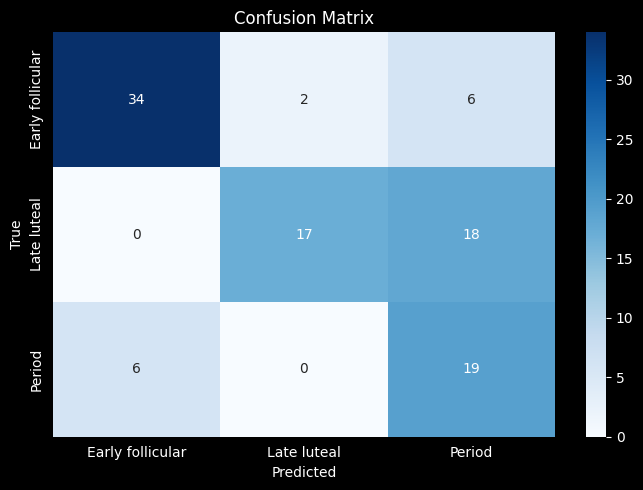

In [51]:
# 1) Confusion Matrix (Seaborn)
labels = np.unique(np.concatenate([np.array(y_test), np.array(y_pred)]))
cm = confusion_matrix(y_test, y_pred, labels=labels)

tick_labels = labels

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=tick_labels, yticklabels=tick_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()


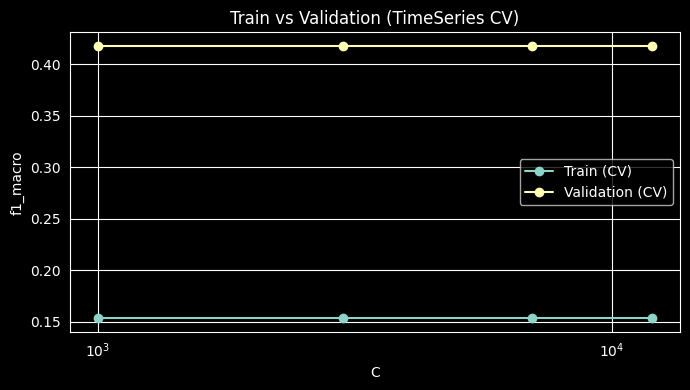

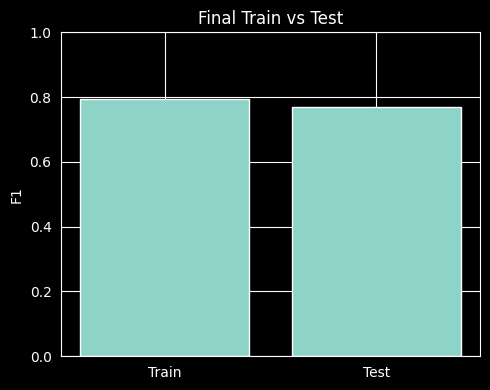

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score

# 1) Train/Validation curve from GridSearchCV
# cv_df = pd.DataFrame(grid.cv_results_).sort_values("param_clf__C")
cv_df = pd.DataFrame(grid.cv_results_).copy()
best_C = grid.best_params_["clf__C"]
best_tol = grid.best_params_["clf__tol"]

sub = cv_df[
    (cv_df["param_clf__C"] == best_C) &
    (cv_df["param_clf__tol"] == best_tol)
].sort_values("param_clf__max_iter")

plt.figure(figsize=(7,4))
plt.plot(sub["param_clf__max_iter"], 1 - sub["mean_train_score"], marker="o", label="Train (CV)")
plt.plot(sub["param_clf__max_iter"], 1 - sub["mean_test_score"], marker="o", label="Validation (CV)")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel(f"{scoring_metric}")
plt.title("Train vs Validation (TimeSeries CV)")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Final Train vs Test
y_train_pred = best.predict(X_train)
y_test_pred = best.predict(X_test)

train_score = f1_score(y_train, y_train_pred, average="macro")
test_score = f1_score(y_test, y_test_pred, average="macro")

plt.figure(figsize=(5,4))
plt.bar(["Train", "Test"], [train_score, test_score])
plt.ylim(0, 1)
plt.ylabel("F1")
plt.title("Final Train vs Test")
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------
# 7) Feature relevance scan
# -------------------------
# This checks whether each feature has standalone predictive signal in time-series CV.
# Treat it as a screening tool: correlated lag/rolling variants can split importance.

def clean_feature_name(name):
    return name.replace("num__", "", 1)


def feature_family(name):
    name = clean_feature_name(name)
    for token in ["_lag", "_roll", "_diff", "_slope"]:
        if token in name:
            base, value = name.rsplit(token, 1)
            return pd.Series({"base_metric": base, "feature_type": token[1:], "window": int(value)})
    return pd.Series({"base_metric": name, "feature_type": "raw", "window": 0})


single_feature_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        solver="lbfgs",
        max_iter=10000,
        class_weight="balanced",
        random_state=42,
    )),
])

rows = []
for col in X_train.select_dtypes(include=[np.number]).columns:
    try:
        scores = cross_val_score(
            single_feature_pipe,
            X_train[[col]],
            y_train,
            cv=TimeSeriesSplit(n_splits=5),
            scoring=scoring_metric,
            n_jobs=-1,
        )
        rows.append({
            "feature": col,
            "cv_mean": scores.mean(),
            "cv_std": scores.std(),
            "missing_pct": X_train[col].isna().mean() * 100,
        })
    except ValueError as exc:
        rows.append({
            "feature": col,
            "cv_mean": np.nan,
            "cv_std": np.nan,
            "missing_pct": X_train[col].isna().mean() * 100,
            "error": str(exc),
        })

feature_scan = pd.DataFrame(rows)
feature_scan = pd.concat([feature_scan, feature_scan["feature"].apply(feature_family)], axis=1)
feature_scan = feature_scan.sort_values("cv_mean", ascending=False)

print("Top individual features by time-series CV score:")
display(feature_scan.head(25))

print("Best window per base metric + feature type:")
best_windows = (
    feature_scan
    .dropna(subset=["cv_mean"])
    .sort_values("cv_mean", ascending=False)
    .groupby(["base_metric", "feature_type"], as_index=False)
    .first()
    .sort_values("cv_mean", ascending=False)
)
display(best_windows.head(40))

plt.figure(figsize=(10, 5))
sns.barplot(
    data=feature_scan.head(25),
    x="cv_mean",
    y="feature",
    hue="feature_type",
    dodge=False,
)
plt.xlabel(scoring_metric)
plt.ylabel("")
plt.title("Top Candidate Features by Time-Series CV")
plt.tight_layout()
plt.show()


Top individual features by time-series CV score:


,feature,cv_mean,cv_std,missing_pct,base_metric,feature_type,window
48,resting_hr_diff7,0.484752,0.099915,1.724138,resting_hr,diff,7
50,resting_hr_slope7,0.479948,0.077897,1.724138,resting_hr,slope,7
51,resting_hr_slope14,0.479216,0.114715,3.448276,resting_hr,slope,14
101,avg_sleep_respiration_diff3,0.457474,0.081917,2.955665,avg_sleep_respiration,diff,3
33,hrv_rmssd_slope14,0.434933,0.083115,20.689655,hrv_rmssd,slope,14
103,avg_sleep_respiration_slope5,0.417413,0.083886,6.157635,avg_sleep_respiration,slope,5
86,avgStressLevel_slope7,0.413650,0.083762,1.724138,avgStressLevel,slope,7
49,resting_hr_slope5,0.401528,0.020482,1.231527,resting_hr,slope,5
87,avgStressLevel_slope14,0.398011,0.091486,3.448276,avgStressLevel,slope,14
32,hrv_rmssd_slope7,0.394874,0.098872,10.344828,hrv_rmssd,slope,7


Best window per base metric + feature type:


,base_metric,feature_type,feature,cv_mean,cv_std,missing_pct,window
25,resting_hr,diff,resting_hr_diff7,0.484752,0.099915,1.724138,7
29,resting_hr,slope,resting_hr_slope7,0.479948,0.077897,1.724138,7
6,avg_sleep_respiration,diff,avg_sleep_respiration_diff3,0.457474,0.081917,2.955665,3
21,hrv_rmssd,slope,hrv_rmssd_slope14,0.434933,0.083115,20.689655,14
10,avg_sleep_respiration,slope,avg_sleep_respiration_slope5,0.417413,0.083886,6.157635,5
5,avgStressLevel,slope,avgStressLevel_slope7,0.413650,0.083762,1.724138,7
17,hrv_rmssd,diff,hrv_rmssd_diff7,0.393869,0.073090,4.433498,7
1,avgStressLevel,diff,avgStressLevel_diff7,0.389289,0.065939,1.724138,7
28,resting_hr,roll,resting_hr_roll3,0.383598,0.066075,0.738916,3
26,resting_hr,lag,resting_hr_lag2,0.383580,0.084099,0.492611,2
